# AR vs Spectrum Decay From Precomputed Metrics

This notebook reads the merged output from the Slurm analysis pipeline and reproduces the lightweight analysis views without recomputing eigenspectra or AR errors.


In [1]:
from pathlib import Path
import json
import math
import random

import matplotlib.pyplot as plt
import numpy as np

METRICS_DIR = Path('/workspace/outputs/offline_math500_temp1_k32/qwen2_5_3b_limit500/merged/analysis_parallel/merged')
METRICS_PATH = METRICS_DIR / 'metrics.jsonl'
SUMMARY_PATH = METRICS_DIR / 'summary.json'
RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

def load_jsonl(path: Path):
    rows = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

assert METRICS_PATH.exists(), f'missing metrics: {METRICS_PATH}'
samples = load_jsonl(METRICS_PATH)
print('Loaded samples:', len(samples))
if SUMMARY_PATH.exists():
    print(SUMMARY_PATH.read_text(encoding='utf-8'))


Loaded samples: 15990
{
  "input_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen2_5_3b_limit500/merged/analysis_parallel/shards",
  "output_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen2_5_3b_limit500/merged/analysis_parallel/merged",
  "num_metric_files": 40,
  "merged_rows": 15990,
  "source_summaries": [
    {
      "run_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen2_5_3b_limit500/merged",
      "output_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen2_5_3b_limit500/merged/analysis_parallel/shards",
      "metrics_path": "/workspace/outputs/offline_math500_temp1_k32/qwen2_5_3b_limit500/merged/analysis_parallel/shards/metrics_shard_00.jsonl",
      "num_shards": 40,
      "shard_index": 0,
      "selected_uids": 400,
      "processed_rows": 400,
      "written_rows": 400,
      "skipped_short": 0,
      "ar_checkpoint": "/workspace/outputs/offline_math500_temp1_k32/qwen2_5_3b_limit500/merged/analysis_parallel/ar_model/checkpoints/latest.pt",
   

In [ ]:
# Optional filter: remove trajectories that hit the response-length cap before recomputing summaries.
EXCLUDE_TRUNCATED_RESPONSES = False
TRUNCATION_LENGTH_CUTOFF = 4096

samples_all = samples
if EXCLUDE_TRUNCATED_RESPONSES:
    before = len(samples_all)
    samples = [s for s in samples_all if int(s['response_length']) < TRUNCATION_LENGTH_CUTOFF]
    print(f'Filtered samples with response_length >= {TRUNCATION_LENGTH_CUTOFF}:', before - len(samples))
    print('Samples after truncation filter:', len(samples))
else:
    samples = samples_all
    print('Samples after truncation filter:', len(samples))


In [ ]:
# Optional filter: keep only questions that have both success and failure trajectories.
MIXED_QUESTIONS_ONLY = False

from collections import defaultdict

if 'all_samples' in globals():
    samples_source = all_samples
    by_q = defaultdict(list)
    for s in samples_source:
        by_q[s['question_uid']].append(s)
    mixed_qids = {qid for qid, group in by_q.items() if any(x['success'] for x in group) and any((not x['success']) for x in group)}
    if MIXED_QUESTIONS_ONLY:
        before = len(samples_source)
        all_samples = [s for s in samples_source if s['question_uid'] in mixed_qids]
        if 'samples' in globals():
            samples = all_samples
        print('Mixed-question filter removed:', before - len(all_samples))
    print('Mixed questions:', len(mixed_qids))
    print('Samples after mixed-question filter:', len(all_samples))
else:
    samples_source = samples
    by_q = defaultdict(list)
    for s in samples_source:
        by_q[s['question_uid']].append(s)
    mixed_qids = {qid for qid, group in by_q.items() if any(x['success'] for x in group) and any((not x['success']) for x in group)}
    if MIXED_QUESTIONS_ONLY:
        before = len(samples_source)
        samples = [s for s in samples_source if s['question_uid'] in mixed_qids]
        print('Mixed-question filter removed:', before - len(samples))
    print('Mixed questions:', len(mixed_qids))
    print('Samples after mixed-question filter:', len(samples))


In [ ]:
# Trend uncertainty band mode for binned mean plots.
TREND_ERROR_MODE = 'stderr'  # one of: 'stderr', 'std'
assert TREND_ERROR_MODE in {'stderr', 'std'}
print('TREND_ERROR_MODE =', TREND_ERROR_MODE)


In [ ]:
def summarize(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'n': int(arr.size),
        'mean': float(arr.mean()) if arr.size else None,
        'median': float(np.median(arr)) if arr.size else None,
        'std': float(arr.std()) if arr.size else None,
        'min': float(arr.min()) if arr.size else None,
        'max': float(arr.max()) if arr.size else None,
    }

success_ar = [s['ar_error'] for s in samples if s['success']]
failure_ar = [s['ar_error'] for s in samples if not s['success']]
success_decay = [s['decay_rate'] for s in samples if s['success']]
failure_decay = [s['decay_rate'] for s in samples if not s['success']]

print('Success AR error stats:', summarize(success_ar))
print('Failure AR error stats:', summarize(failure_ar))
print('Success decay stats:', summarize(success_decay))
print('Failure decay stats:', summarize(failure_decay))


Success AR error stats: {'n': 131, 'mean': 3.169506133057689, 'std': 0.7414915753099652, 'min': 1.8476581573486328, 'max': 5.886600971221924}
Failure AR error stats: {'n': 15859, 'mean': 3.1536606845853306, 'std': 0.6379747840301333, 'min': 1.6645729541778564, 'max': 6.743319511413574}
Success decay stats: {'n': 131, 'mean': 1.4525170216939283, 'std': 2.161310554395981, 'min': 0.9586425241544022, 'max': 15.7513959548531}
Failure decay stats: {'n': 15859, 'mean': 1.4484806408182485, 'std': 1.9859581611315245, 'min': 0.9177637036389894, 'max': 15.788045053399976}


Pearson correlation(decay_rate, ar_error): 0.2022747520016305


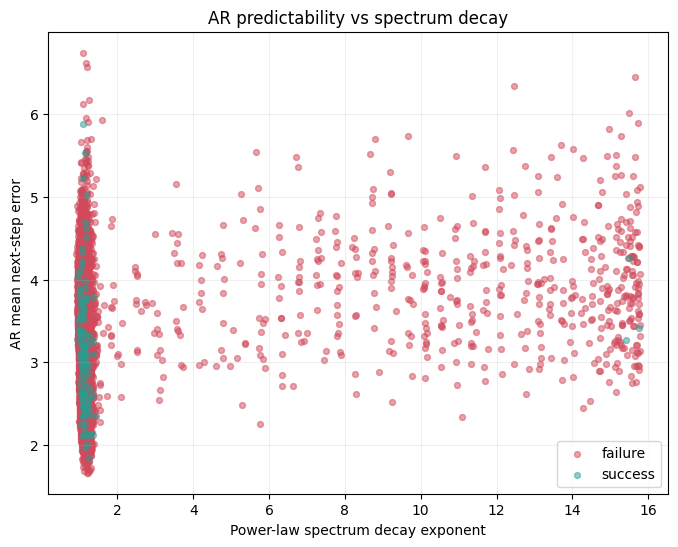

In [3]:
# Correlation between AR error and spectrum decay.
x = np.asarray([s['decay_rate'] for s in samples], dtype=np.float64)
y = np.asarray([s['ar_error'] for s in samples], dtype=np.float64)
labels = np.asarray([1 if s['success'] else 0 for s in samples], dtype=np.int64)

valid = x < np.percentile(x, 99.99)
x = x[valid]
y = y[valid]
labels = labels[valid]

corr = np.corrcoef(x, y)[0, 1]
print('Pearson correlation(decay_rate, ar_error):', float(corr))

plt.figure(figsize=(8, 6))
failure = labels == 0
success = labels == 1
if failure.any():
    plt.scatter(x[failure], y[failure], s=18, alpha=0.5, c='#d1495b', label='failure')
if success.any():
    plt.scatter(x[success], y[success], s=18, alpha=0.5, c='#2a9d8f', label='success')
plt.xlabel('Power-law spectrum decay exponent')
plt.ylabel('AR mean next-step error')
plt.title('AR predictability vs spectrum decay')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


Pairwise correlations:
Response length vs Analysis length: Pearson=0.0011, Spearman=0.0044
Response length vs Power-law decay: Pearson=0.0018, Spearman=-0.0056
Response length vs AR error: Pearson=-0.0246, Spearman=-0.0074
Analysis length vs Power-law decay: Pearson=-0.1778, Spearman=-0.5864
Analysis length vs AR error: Pearson=0.3519, Spearman=0.0719
Power-law decay vs AR error: Pearson=0.2032, Spearman=-0.3522


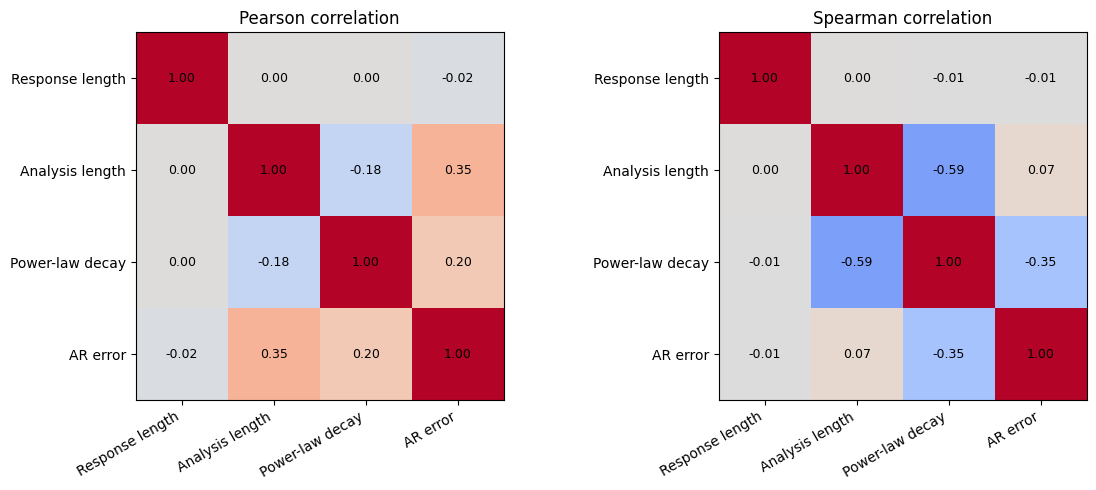

In [4]:
# Correlation analysis across length, decay, and AR error.
def rankdata_average(a):
    a = np.asarray(a, dtype=np.float64)
    order = np.argsort(a, kind='mergesort')
    ranks = np.empty(len(a), dtype=np.float64)
    i = 0
    while i < len(a):
        j = i + 1
        while j < len(a) and a[order[j]] == a[order[i]]:
            j += 1
        avg_rank = 0.5 * (i + j - 1) + 1.0
        ranks[order[i:j]] = avg_rank
        i = j
    return ranks

def spearman_corr(x, y):
    rx = rankdata_average(x)
    ry = rankdata_average(y)
    return float(np.corrcoef(rx, ry)[0, 1])

metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
]
metric_arrays = {key: np.asarray([float(s[key]) for s in samples], dtype=np.float64) for key, _ in metric_specs}
labels = [label for _, label in metric_specs]
pearson = np.zeros((len(metric_specs), len(metric_specs)), dtype=np.float64)
spearman = np.zeros_like(pearson)
for i, (key_i, _) in enumerate(metric_specs):
    for j, (key_j, _) in enumerate(metric_specs):
        xi = metric_arrays[key_i]
        xj = metric_arrays[key_j]
        pearson[i, j] = float(np.corrcoef(xi, xj)[0, 1])
        spearman[i, j] = spearman_corr(xi, xj)

print('Pairwise correlations:')
for i in range(len(metric_specs)):
    for j in range(i + 1, len(metric_specs)):
        print(f'{labels[i]} vs {labels[j]}: Pearson={pearson[i, j]:.4f}, Spearman={spearman[i, j]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title in zip(axes, [pearson, spearman], ['Pearson correlation', 'Spearman correlation']):
    im = ax.imshow(matrix, cmap='coolwarm', vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()


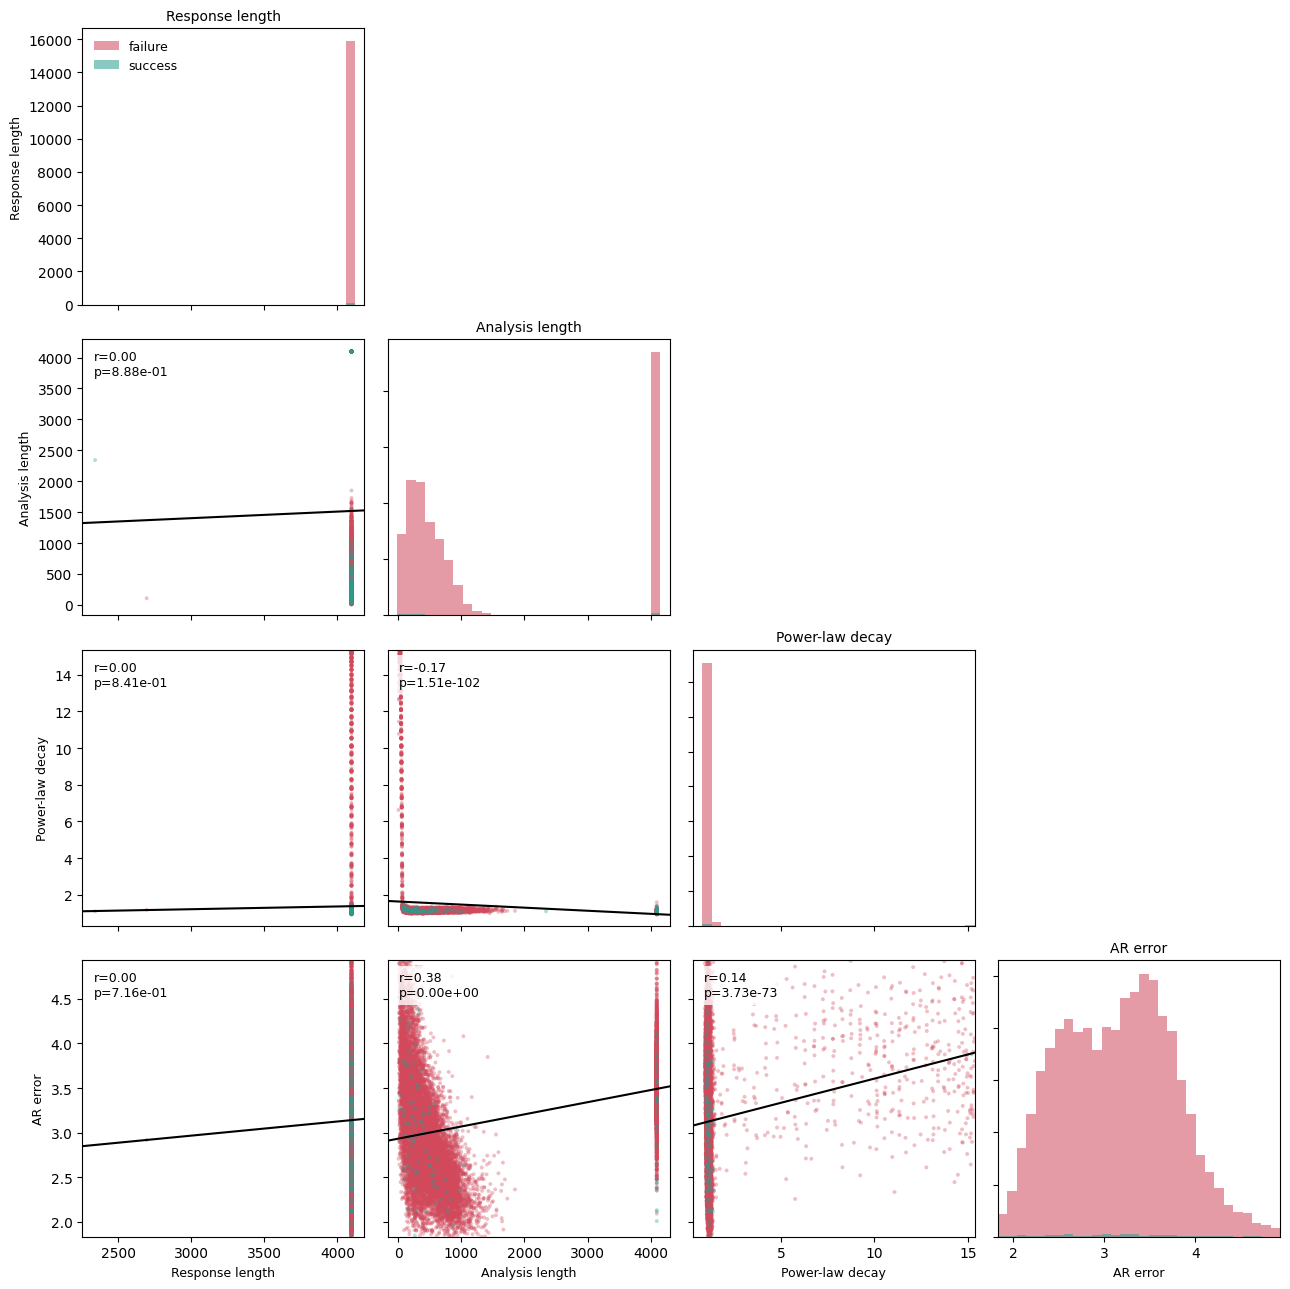

In [5]:
# Lower-triangle regression matrix across scalar metrics.
def pearson_pvalue(r, n):
    if n < 4 or not np.isfinite(r):
        return np.nan
    r = float(np.clip(r, -0.999999, 0.999999))
    z = abs(np.arctanh(r)) * np.sqrt(max(n - 3, 1))
    return float(math.erfc(z / np.sqrt(2.0)))

def robust_limits(x, lo=1.0, hi=99.0, pad_frac=0.05):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (0.0, 1.0)
    lo_v, hi_v = np.percentile(x, [lo, hi])
    if not np.isfinite(lo_v) or not np.isfinite(hi_v):
        lo_v, hi_v = float(np.min(x)), float(np.max(x))
    if hi_v <= lo_v:
        lo_v, hi_v = float(np.min(x)), float(np.max(x))
    span = hi_v - lo_v
    if span <= 0:
        span = max(abs(lo_v), 1.0) * pad_frac
    pad = span * pad_frac
    return (float(lo_v - pad), float(hi_v + pad))

metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
]
metric_arrays = {key: np.asarray([float(s[key]) for s in samples], dtype=np.float64) for key, _ in metric_specs}
metric_limits = {key: robust_limits(vals) for key, vals in metric_arrays.items()}
success_mask = np.asarray([bool(s['success']) for s in samples], dtype=bool)
failure_mask = ~success_mask
n_metrics = len(metric_specs)
fig, axes = plt.subplots(n_metrics, n_metrics, figsize=(13, 13))
for i in range(n_metrics):
    for j in range(n_metrics):
        ax = axes[i, j]
        if i < j:
            ax.axis('off')
            continue
        key_x, label_x = metric_specs[j]
        key_y, label_y = metric_specs[i]
        x = metric_arrays[key_x]
        y = metric_arrays[key_y]
        if i == j:
            bins = np.linspace(metric_limits[key_x][0], metric_limits[key_x][1], 31)
            if failure_mask.any():
                ax.hist(x[failure_mask], bins=bins, color='#d1495b', alpha=0.55, label='failure')
            if success_mask.any():
                ax.hist(x[success_mask], bins=bins, color='#2a9d8f', alpha=0.55, label='success')
            ax.set_xlim(*metric_limits[key_x])
            ax.set_title(label_x, fontsize=10)
            if i == 0 and j == 0:
                ax.legend(frameon=False, fontsize=9)
        else:
            valid = (
                np.isfinite(x) & np.isfinite(y) &
                (x >= metric_limits[key_x][0]) & (x <= metric_limits[key_x][1]) &
                (y >= metric_limits[key_y][0]) & (y <= metric_limits[key_y][1])
            )
            x_plot = x[valid]
            y_plot = y[valid]
            success_plot = success_mask[valid]
            failure_plot = failure_mask[valid]
            if failure_plot.any():
                ax.scatter(x_plot[failure_plot], y_plot[failure_plot], s=8, c='#d1495b', alpha=0.35, edgecolors='none')
            if success_plot.any():
                ax.scatter(x_plot[success_plot], y_plot[success_plot], s=8, c='#2a9d8f', alpha=0.35, edgecolors='none')
            if x_plot.size >= 2:
                coeffs = np.polyfit(x_plot, y_plot, deg=1)
                xs = np.linspace(metric_limits[key_x][0], metric_limits[key_x][1], 100)
                ys = coeffs[0] * xs + coeffs[1]
                ax.plot(xs, ys, color='black', lw=1.5)
                r = float(np.corrcoef(x_plot, y_plot)[0, 1])
                pval = pearson_pvalue(r, len(x_plot))
                ax.text(0.04, 0.96, f'r={r:.2f}\np={pval:.2e}', transform=ax.transAxes, va='top', ha='left', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            ax.set_xlim(*metric_limits[key_x])
            ax.set_ylim(*metric_limits[key_y])
        if i == n_metrics - 1:
            ax.set_xlabel(label_x, fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(label_y, fontsize=9)
        else:
            ax.set_yticklabels([])
plt.tight_layout()
plt.show()


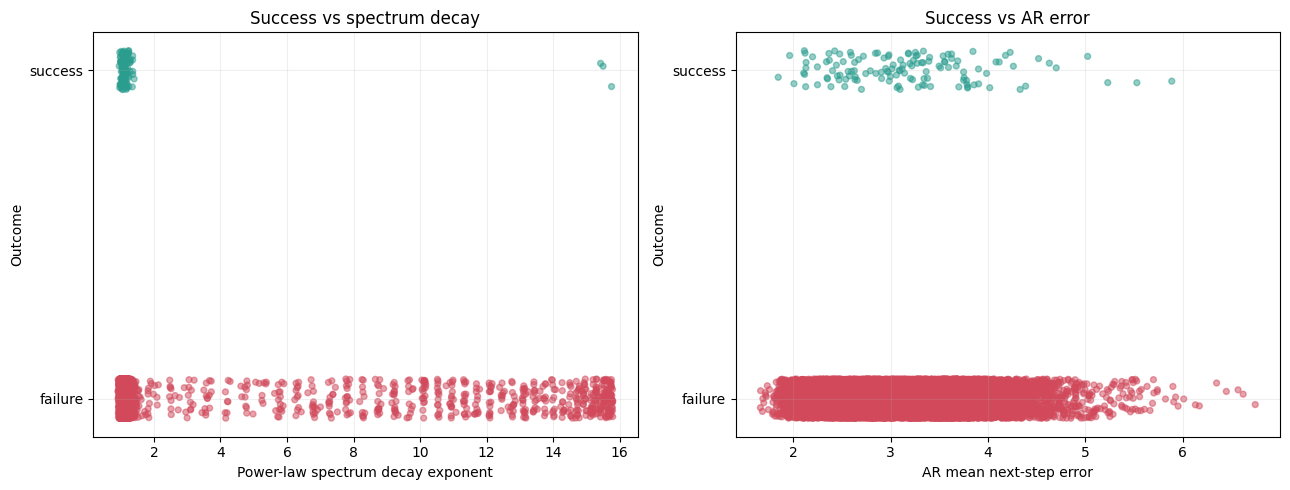

In [6]:
# Success vs AR error and success vs decay.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y_outcome = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)
y_jitter = y_outcome + np.random.uniform(-0.06, 0.06, size=len(y_outcome))

axes[0].scatter(np.asarray([s['decay_rate'] for s in samples]), y_jitter, c=np.where(y_outcome > 0.5, '#2a9d8f', '#d1495b'), s=18, alpha=0.5)
axes[0].set_yticks([0, 1], ['failure', 'success'])
axes[0].set_xlabel('Power-law spectrum decay exponent')
axes[0].set_ylabel('Outcome')
axes[0].set_title('Success vs spectrum decay')
axes[0].grid(alpha=0.2)

axes[1].scatter(np.asarray([s['ar_error'] for s in samples]), y_jitter, c=np.where(y_outcome > 0.5, '#2a9d8f', '#d1495b'), s=18, alpha=0.5)
axes[1].set_yticks([0, 1], ['failure', 'success'])
axes[1].set_xlabel('AR mean next-step error')
axes[1].set_ylabel('Outcome')
axes[1].set_title('Success vs AR error')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [7]:
def cliffs_delta(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.size == 0 or y.size == 0:
        return None
    total = 0
    for xv in x:
        total += np.sum(xv > y) - np.sum(xv < y)
    return float(total / (x.size * y.size))


def permutation_mean_diff(x, y, n_perm=2000, seed=1):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    observed = float(x.mean() - y.mean())
    pooled = np.concatenate([x, y]).copy()
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:x.size]
        yp = pooled[x.size:]
        diff = xp.mean() - yp.mean()
        if abs(diff) >= abs(observed):
            count += 1
    p = (count + 1) / (n_perm + 1)
    return observed, p

for name, sx, fx in [
    ('decay_rate', success_decay, failure_decay),
    ('ar_error', success_ar, failure_ar),
]:
    obs, pval = permutation_mean_diff(sx, fx, n_perm=2000, seed=RANDOM_SEED)
    print(name)
    print('  mean(success) - mean(failure):', obs)
    print('  cliffs_delta(success, failure):', cliffs_delta(sx, fx))
    print('  permutation p-value:', pval)


decay_rate
  mean(success) - mean(failure): 0.0040363808756798125
  cliffs_delta(success, failure): 0.11730425905005418
  permutation p-value: 0.9865067466266867
ar_error
  mean(success) - mean(failure): 0.01584544847235847
  cliffs_delta(success, failure): -0.01953618938652601
  permutation p-value: 0.7796101949025487


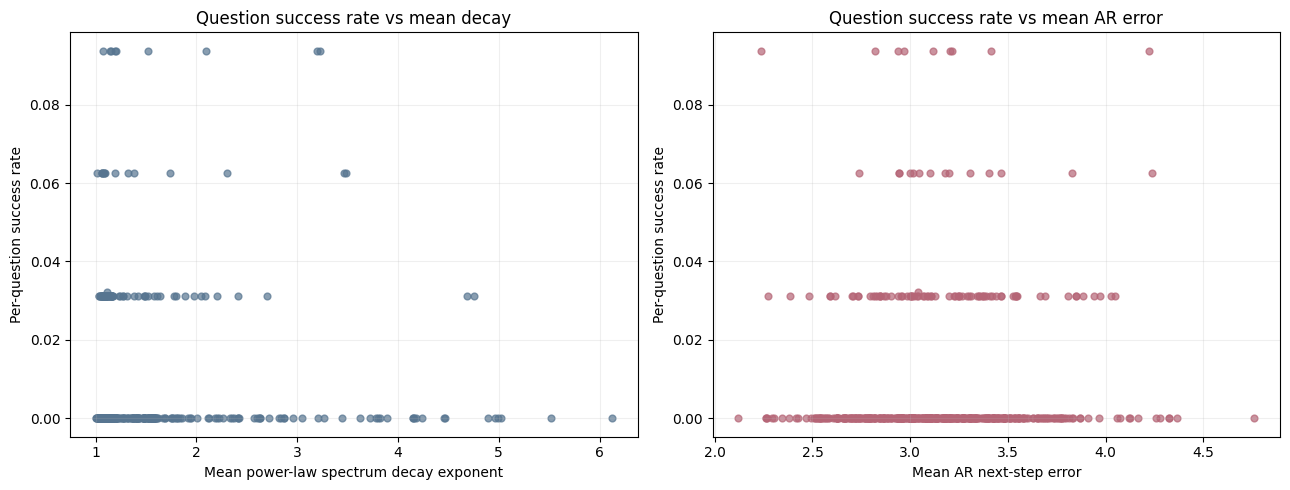

In [8]:
# Question-level summary: does mean decay or mean AR error track question difficulty?
by_question = {}
for item in samples:
    by_question.setdefault(item['question_uid'], []).append(item)

question_rows = []
for qid, group in by_question.items():
    succ = np.asarray([1.0 if x['success'] else 0.0 for x in group], dtype=np.float64)
    dec = np.asarray([x['decay_rate'] for x in group], dtype=np.float64)
    ar = np.asarray([x['ar_error'] for x in group], dtype=np.float64)
    question_rows.append({
        'question_uid': qid,
        'n_samples': len(group),
        'success_rate': float(succ.mean()),
        'mean_decay_rate': float(dec.mean()),
        'std_decay_rate': float(dec.std()),
        'mean_ar_error': float(ar.mean()),
        'std_ar_error': float(ar.std()),
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter([r['mean_decay_rate'] for r in question_rows], [r['success_rate'] for r in question_rows], s=24, alpha=0.7, c='#577590')
axes[0].set_xlabel('Mean power-law spectrum decay exponent')
axes[0].set_ylabel('Per-question success rate')
axes[0].set_title('Question success rate vs mean decay')
axes[0].grid(alpha=0.2)

axes[1].scatter([r['mean_ar_error'] for r in question_rows], [r['success_rate'] for r in question_rows], s=24, alpha=0.7, c='#b56576')
axes[1].set_xlabel('Mean AR next-step error')
axes[1].set_ylabel('Per-question success rate')
axes[1].set_title('Question success rate vs mean AR error')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Side-by-Side Metric Comparison

This section compares `response_length`, `analysis_length`, `decay_rate`, and `ar_error` using the same descriptive views so you can see whether spectrum/AR effects are stronger or different than plain length effects.


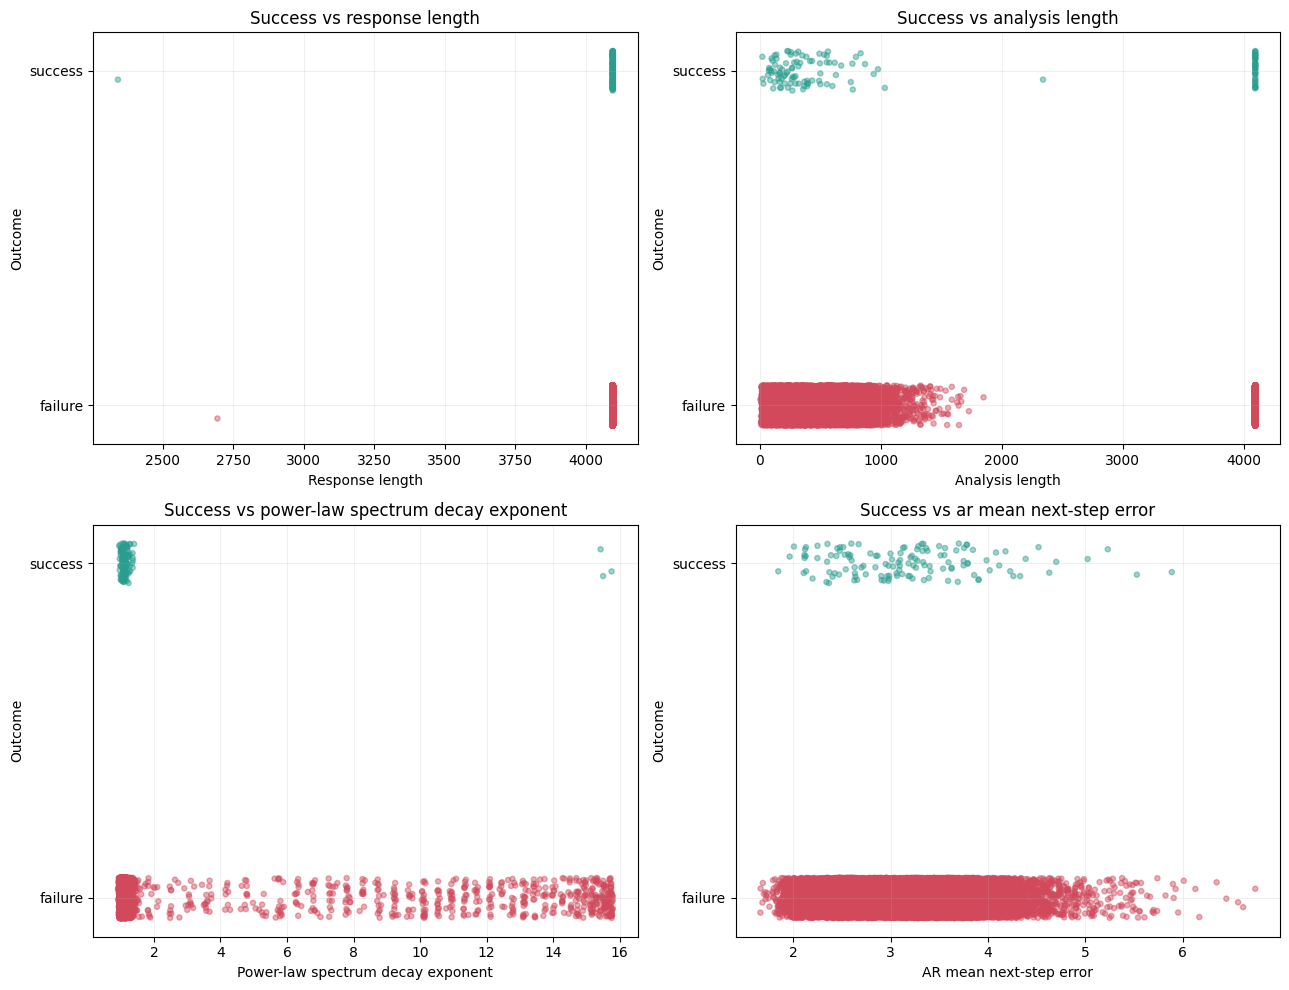

In [9]:
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law spectrum decay exponent'),
    ('ar_error', 'AR mean next-step error'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
outcome = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)
outcome_jitter = outcome + np.random.uniform(-0.06, 0.06, size=len(outcome))
colors = np.where(outcome > 0.5, '#2a9d8f', '#d1495b')

for ax, (key, label) in zip(axes, metric_specs):
    vals = np.asarray([s[key] for s in samples], dtype=np.float64)
    ax.scatter(vals, outcome_jitter, c=colors, s=14, alpha=0.45)
    ax.set_yticks([0, 1], ['failure', 'success'])
    ax.set_xlabel(label)
    ax.set_ylabel('Outcome')
    ax.set_title(f'Success vs {label.lower()}')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


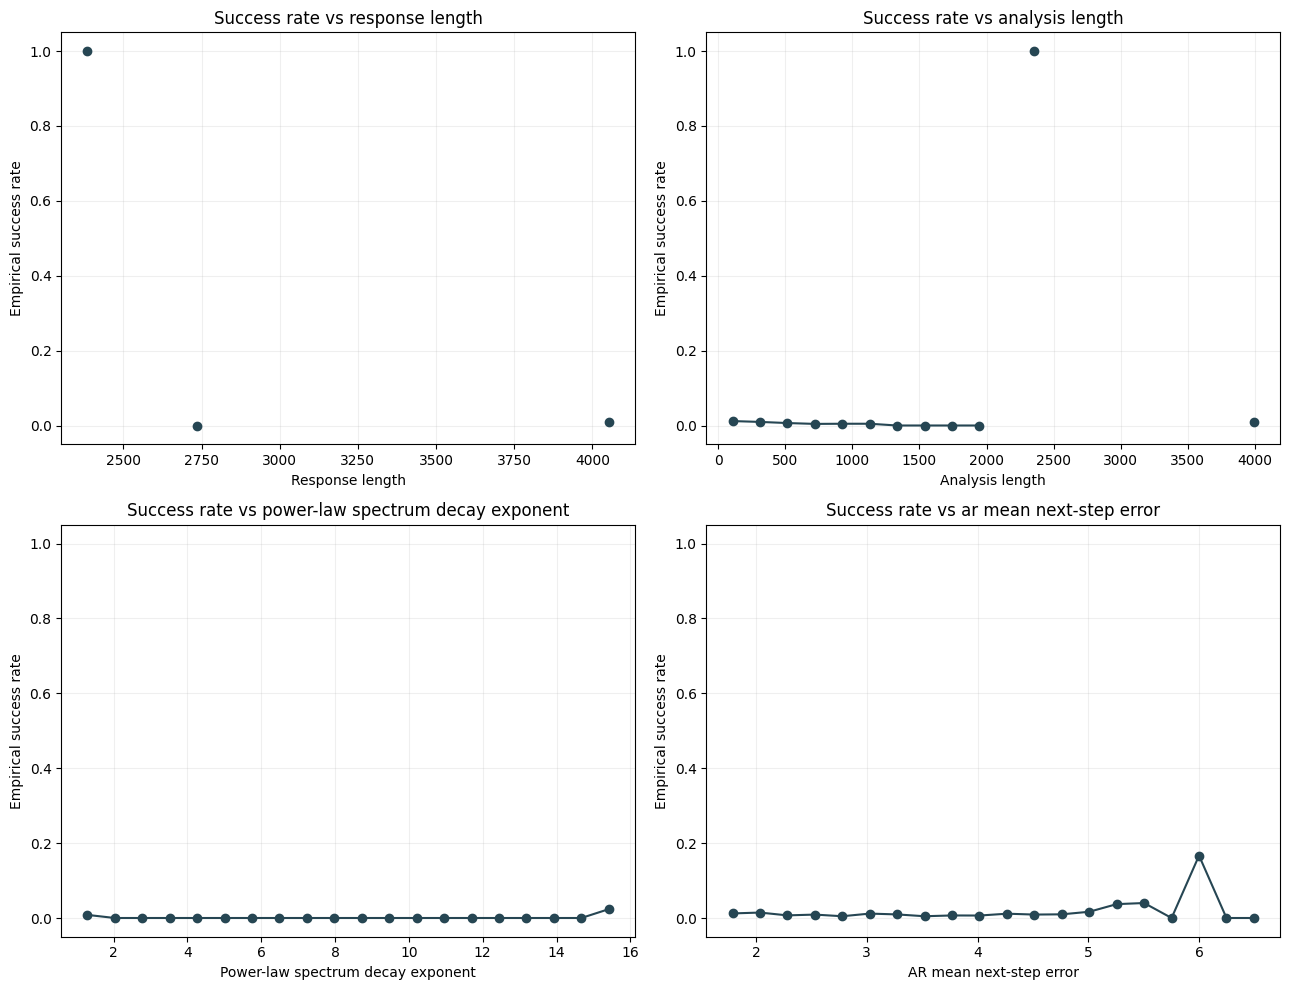

In [10]:
def binned_success_rate_from_values(values, success, n_bins=20, error_mode=TREND_ERROR_MODE):
    x = np.asarray(values, dtype=np.float64)
    y = np.asarray(success, dtype=np.float64)
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rates = []
    counts = []
    errs = []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        if i == len(edges) - 2:
            mask = (x >= lo) & (x <= hi)
        else:
            mask = (x >= lo) & (x < hi)
        if mask.any():
            vals = y[mask]
            rates.append(float(vals.mean()))
            counts.append(int(mask.sum()))
            if vals.size > 1:
                std = float(vals.std(ddof=1))
            else:
                std = 0.0
            errs.append(std / math.sqrt(vals.size) if error_mode == 'stderr' else std)
        else:
            rates.append(np.nan)
            counts.append(0)
            errs.append(np.nan)
    return centers, np.asarray(rates), np.asarray(counts), np.asarray(errs)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
success01 = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)

for ax, (key, label) in zip(axes, metric_specs):
    vals = np.asarray([s[key] for s in samples], dtype=np.float64)
    valid = np.percentile(vals, 99.999)
    vals_valid = vals[vals <= valid]
    success01_valid = success01[vals <= valid]
    centers, rates, counts, errs = binned_success_rate_from_values(vals_valid, success01_valid, n_bins=20, error_mode=TREND_ERROR_MODE)
    ax.plot(centers, rates, marker='o', color='#264653')
    ax.fill_between(centers, rates - errs, rates + errs, color='#264653', alpha=0.15)
    ax.set_xlabel(label)
    ax.set_ylabel('Empirical success rate')
    ax.set_title(f'Success rate vs {label.lower()}')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.2)
plt.suptitle('Shaded band = selected uncertainty mode', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


## Within-Question Paired Comparisons

This section compares successful and failed samples **within the same question**. This is the main nonparametric control for question difficulty and avoids assuming an additive model.


In [11]:
by_question = {}
for item in samples:
    by_question.setdefault(item['question_uid'], []).append(item)

paired_metric_gaps = {key: [] for key, _ in metric_specs}
paired_counts = 0
for qid, group in by_question.items():
    succ = [x for x in group if x['success']]
    fail = [x for x in group if not x['success']]
    if not succ or not fail:
        continue
    paired_counts += 1
    for key, _ in metric_specs:
        succ_mean = float(np.mean([x[key] for x in succ]))
        fail_mean = float(np.mean([x[key] for x in fail]))
        paired_metric_gaps[key].append(fail_mean - succ_mean)

print('Questions with both success and failure:', paired_counts)
for key, label in metric_specs:
    vals = np.asarray(paired_metric_gaps[key], dtype=np.float64)
    print(label, summarize(vals))


Questions with both success and failure: 99
Response length {'n': 99, 'mean': 8.863636363636363, 'std': 87.74552330178521, 'min': 0.0, 'max': 877.5}
Analysis length {'n': 99, 'mean': 29.87839687194527, 'std': 1657.8160814430962, 'min': -3379.1612903225805, 'max': 3059.1612903225805}
Power-law spectrum decay exponent {'n': 99, 'mean': 0.07646480191103677, 'std': 1.382694681947314, 'min': -11.350835944383217, 'max': 3.8427704080784992}
AR mean next-step error {'n': 99, 'mean': 0.024606022843198294, 'std': 0.5274014311843556, 'min': -1.6065735047863376, 'max': 0.9100664200321322}


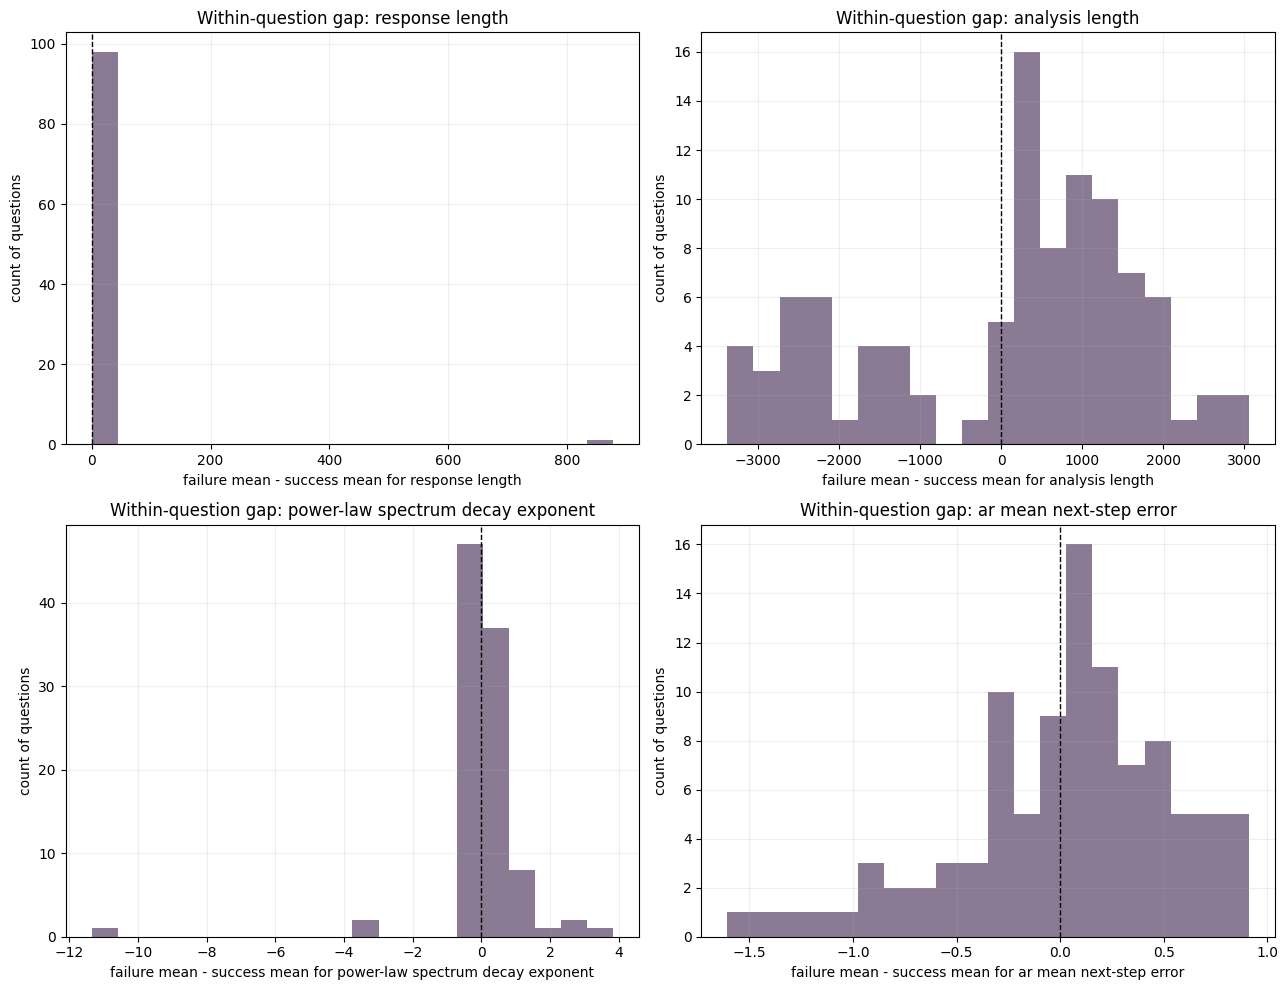

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
for ax, (key, label) in zip(axes, metric_specs):
    vals = np.asarray(paired_metric_gaps[key], dtype=np.float64)
    ax.hist(vals, bins=20, color='#6d597a', alpha=0.8)
    ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel(f'failure mean - success mean for {label.lower()}')
    ax.set_ylabel('count of questions')
    ax.set_title(f'Within-question gap: {label.lower()}')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [13]:
def paired_sign_summary(values, name):
    vals = np.asarray(values, dtype=np.float64)
    pos = int(np.sum(vals > 0))
    neg = int(np.sum(vals < 0))
    zero = int(np.sum(vals == 0))
    print(name)
    print('  positive:', pos)
    print('  negative:', neg)
    print('  zero:', zero)
    print('  mean gap:', float(vals.mean()) if vals.size else None)
    print('  median gap:', float(np.median(vals)) if vals.size else None)

for key, label in metric_specs:
    paired_sign_summary(paired_metric_gaps[key], label)


Response length
  positive: 1
  negative: 0
  zero: 98
  mean gap: 8.863636363636363
Analysis length
  positive: 66
  negative: 33
  zero: 0
  mean gap: 29.87839687194527
Power-law spectrum decay exponent
  positive: 63
  negative: 36
  zero: 0
  mean gap: 0.07646480191103677
AR mean next-step error
  positive: 62
  negative: 37
  zero: 0
  mean gap: 0.024606022843198294
